Epoch 1/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7531 - loss: 0.5855 - val_accuracy: 0.8043 - val_loss: 0.5334
Epoch 2/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9022 - loss: 0.4501 - val_accuracy: 0.8261 - val_loss: 0.4336
Epoch 3/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9242 - loss: 0.3502 - val_accuracy: 0.8913 - val_loss: 0.3557
Epoch 4/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9462 - loss: 0.2687 - val_accuracy: 0.8913 - val_loss: 0.3020
Epoch 5/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9487 - loss: 0.2113 - val_accuracy: 0.8913 - val_loss: 0.2678
Epoch 6/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9511 - loss: 0.1744 - val_accuracy: 0.8913 - val_loss: 0.2431
Epoch 7/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9584 - loss: 0.1497 - val_accuracy: 0.9130 - val_loss: 0.2240
Epoch 8/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9609 - loss: 0.1323 - val_accuracy: 0.9130 - val_loss:

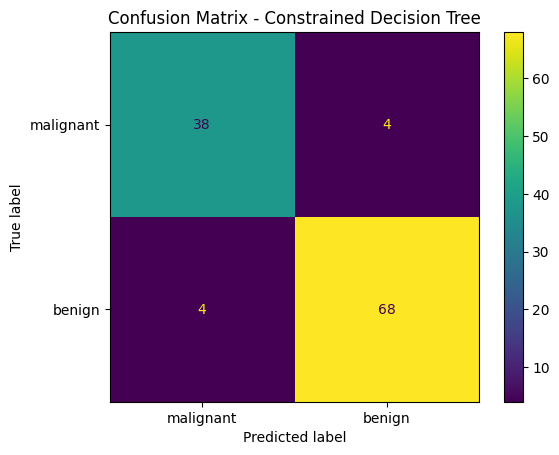


Confusion Matrix - Neural Network
[[39  3]
 [ 3 69]]


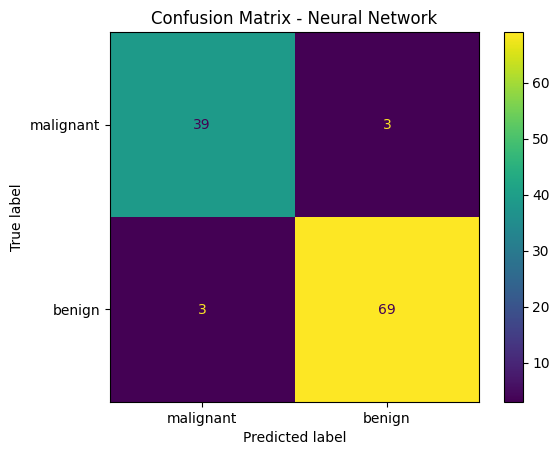

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Load dataset
cancer_data = load_breast_cancer()
X = cancer_data.data
y = cancer_data.target

# 80/20 split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Question 3: Constrained decision tree
constrained_tree_model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4,
    min_samples_split=10,
    random_state=42
)
constrained_tree_model.fit(X_train, y_train)

# Predictions
y_train_pred_constrained = constrained_tree_model.predict(X_train)
y_test_pred_constrained = constrained_tree_model.predict(X_test)

# Decision tree accuracies
train_acc_tree = accuracy_score(y_train, y_train_pred_constrained)
test_acc_tree = accuracy_score(y_test, y_test_pred_constrained)

# Question 4: Neural network
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

neural_network_model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(16, activation="relu"),
    Dense(8, activation="relu"),
    Dense(1, activation="sigmoid")
])

neural_network_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Train neural network
neural_network_model.fit(
    X_train_scaled, y_train,
    epochs=30,
    batch_size=16,
    validation_split=0.1,
    verbose=1
)

# Evaluate on training and test data
train_loss, train_acc = neural_network_model.evaluate(X_train_scaled, y_train, verbose=0)
test_loss, test_acc = neural_network_model.evaluate(X_test_scaled, y_test, verbose=0)

# Neural network predictions
y_test_pred_nn_prob = neural_network_model.predict(X_test_scaled)
y_test_pred_nn = (y_test_pred_nn_prob > 0.5).astype(int).flatten()

# Confusion matrix for constrained decision tree
cm_tree = confusion_matrix(y_test, y_test_pred_constrained)
print("\nConfusion Matrix - Constrained Decision Tree")
print(cm_tree)

disp_tree = ConfusionMatrixDisplay(
    confusion_matrix=cm_tree,
    display_labels=cancer_data.target_names
)
disp_tree.plot()
plt.title("Confusion Matrix - Constrained Decision Tree")
plt.show()

# Confusion matrix for neural network
cm_nn = confusion_matrix(y_test, y_test_pred_nn)
print("\nConfusion Matrix - Neural Network")
print(cm_nn)

disp_nn = ConfusionMatrixDisplay(
    confusion_matrix=cm_nn,
    display_labels=cancer_data.target_names
)
disp_nn.plot()
plt.title("Confusion Matrix - Neural Network")
plt.show()

# I would generally prefer the neural network if it gives better predictive performance,
# but I would prefer the constrained decision tree if interpretability is a priority.
# Decision Tree advantage: easy to interpret.
# Decision Tree limitation: can overfit and may be less stable.
# Neural Network advantage: can model more complex patterns.
# Neural Network limitation: harder to interpret.